<a href="https://colab.research.google.com/github/Tusharchauhan1302/Brain_Tumor_Detection/blob/main/Brain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

Library

In [2]:
import os
import numpy as np
import random
from PIL import Image, ImageEnhance

# Corrected module names below (.models and .layers)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle

Load dataset

In [3]:
# Directories for training and test data
train_dir = '/content/drive/MyDrive/Brain/Training'
test_dir =  '/content/drive/MyDrive/Brain/Testing'

#load and shuffle the train data
train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

train_paths, train_labels = shuffle(train_paths, train_labels)

test_paths = []
test_labels = []
for label in os.listdir(test_dir):
  for image in os.listdir(os.path.join(test_dir, label)):
    test_paths.append(os.path.join(train_dir, label, image))
    test_labels.append(label)

test_path, test_labels = shuffle(test_paths, test_labels)

Data visualization

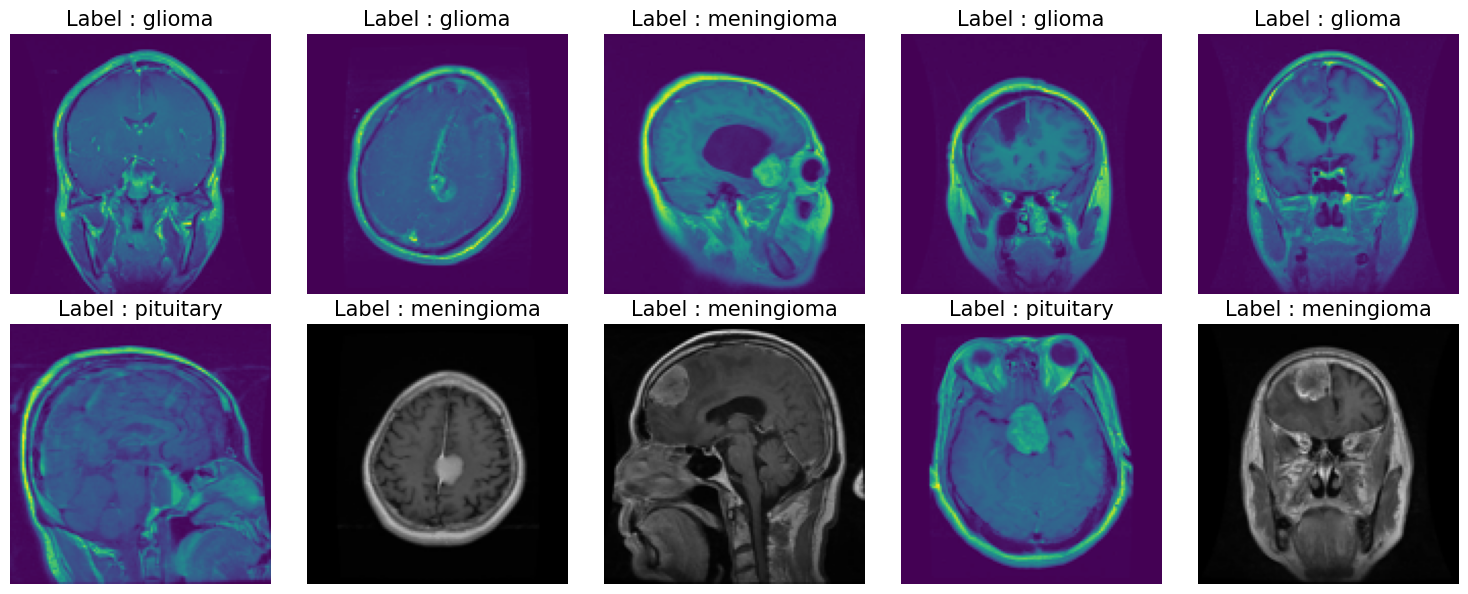

In [4]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os


#Select random indcies for 10 images
random_indices = random.sample(range(len(train_paths)), 10)

# Create a figure to display images in 2 rows
fig, axes = plt.subplots(2,5, figsize=(15, 6))
axes = axes.ravel()

# Loop thorugh the random indcies and display images
for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((128, 128))


  # Display images
  axes[i].imshow(img)
  axes[i].axis("off")
  axes[i].set_title(f"Label : {train_labels[index]}", fontsize = 15)


plt.tight_layout()
plt.show()


Image pre processing

In [5]:
# Image Augmentation Fuction
def augment_image(image):
  pass

# Load images and apply augmenration
def open_images(paths):
  pass

# Encoder labels (Convert labels names to integers)
def encode_labels(labels):
  pass

# Data generator for batching
def data_generator(paths, labels, batch_size= 12, epochs=1):
  pass

In [ ]:
# Model Architecture
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top= False, weigth= 'imagenet')

# Freeze all the layer of VGG16 base model
for layer in base_model.layers:
  layer,trainable = False

# Set only the last few layers
base_model.layers[-2].trainable = True
base_model.layers[-3].trainable = True
base_model.layers[-4].trainable = True

# Build model
model = Sequential()
model.add(Input(shape= (IMAGE_SIZE, IMAGE_SIZE, 3))) #Input layer
model.add(base_model) # VGG16
model.add(Flatten()) # Flatten layer
model.add(Dropout(0.3)) # Dropout layer

model.add(Dense(256, activation= 'relu')) # Dense layer
model.add(Dropout(0.2)) # Dropout layer

model.add(Dense(len(os.listdir(train_dir)), activation = 'softmax')) # output layer

# Compile model
model.Compile(optimizer= Adam(learning_rate=0.0001), loss = 'sparse_categorical_crosstropy')